In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
billets = pd.read_csv("billets.csv", delimiter = ";")

In [3]:
display(billets)

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54
...,...,...,...,...,...,...,...
1495,False,171.75,104.38,104.17,4.42,3.09,111.28
1496,False,172.19,104.63,104.44,5.27,3.37,110.97
1497,False,171.80,104.01,104.12,5.51,3.36,111.95
1498,False,172.06,104.28,104.06,5.17,3.46,112.25


In [4]:
billets.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


In [5]:
billets.isna().sum()

is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

In [6]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [7]:
billets_copy = billets.loc[billets['margin_low'].isna() == False, :]
display(billets_copy.head())
billets_copy.shape

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


(1463, 7)

In [8]:
billets_copy["comp"] = billets_copy.diagonal + billets_copy.height_left + billets_copy.height_right + billets_copy.margin_up + billets_copy.length

C:\Users\agall\AppData\Local\Temp\ipykernel_38008\65507337.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  billets_copy["comp"] = billets_copy.diagonal + billets_copy.height_left + billets_copy.height_right + billets_copy.margin_up + billets_copy.length


In [9]:
variables = ['is_genuine', 'diagonal', 'height_left', 'height_right', 'margin_up', 'length', 'comp']

for i in variables: 
    
    X = billets_copy[i].values.reshape(-1, 1)
    y = billets_copy['margin_low']
    reg.fit(X, y)
    print(f"Score R² pour la variable {i} : {reg.score(X, y)}")


Score R² pour la variable is_genuine : 0.6131393378084237
Score R² pour la variable diagonal : 0.012439850430716604
Score R² pour la variable height_left : 0.09159276027592544
Score R² pour la variable height_right : 0.15294759201240649
Score R² pour la variable margin_up : 0.18628380252698062
Score R² pour la variable length : 0.444559270829349
Score R² pour la variable comp : 0.13324597815991646


In [10]:
billets.corr()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
is_genuine,1.000000,0.132756,-0.379833,-0.485092,-0.783032,-0.606262,0.849285
diagonal,0.132756,1.000000,0.019472,-0.024492,-0.111534,-0.055649,0.097587
height_left,-0.379833,0.019472,1.000000,0.242279,0.302643,0.246522,-0.320863
height_right,-0.485092,-0.024492,0.242279,1.000000,0.391085,0.307005,-0.401751
margin_low,-0.783032,-0.111534,0.302643,0.391085,1.000000,0.431606,-0.666753
margin_up,-0.606262,-0.055649,0.246522,0.307005,0.431606,1.000000,-0.520575
length,0.849285,0.097587,-0.320863,-0.401751,-0.666753,-0.520575,1.000000


In [11]:
X = billets_copy[[ 'is_genuine','diagonal', 'height_left','height_right', 'margin_up', 'length']]
y = billets_copy.margin_low

reg2 = LinearRegression()
reg2.fit(X,y)

print(f"R² : {np.round(reg2.score(X, y), 3)}")

R² : 0.617


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [13]:
y_pred  = reg2.predict(billets_copy[[ 'is_genuine','diagonal', 'height_left','height_right', 'margin_up', 'length']])

In [14]:
print(f"MSE : (y, y_pred): {mean_squared_error(y, y_pred)}")
print(f"MAE : (y, y_pred): {mean_absolute_error(y, y_pred)}")
print(f"MAPE : (y, y_pred): {mean_absolute_percentage_error(y, y_pred)}")

MSE : (y, y_pred): 0.16870708983467025
MAE : (y, y_pred): 0.31581266684460596
MAPE : (y, y_pred): 0.07026071606189062


In [15]:
nan_mask = billets.margin_low.isna()
X_predict = billets.loc[nan_mask, ['is_genuine','diagonal', 'height_left','height_right', 'margin_up', 'length']]
y_pred2 = reg2.predict(X_predict)

billets.loc[nan_mask, 'margin_low'] = y_pred2

display(billets)

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54
...,...,...,...,...,...,...,...
1495,False,171.75,104.38,104.17,4.42,3.09,111.28
1496,False,172.19,104.63,104.44,5.27,3.37,110.97
1497,False,171.80,104.01,104.12,5.51,3.36,111.95
1498,False,172.06,104.28,104.06,5.17,3.46,112.25


In [16]:
billets.isna().sum()

is_genuine      0
diagonal        0
height_left     0
height_right    0
margin_low      0
margin_up       0
length          0
dtype: int64

In [17]:
billets.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.482844,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.659899,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.027500,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


In [18]:
import seaborn as sns

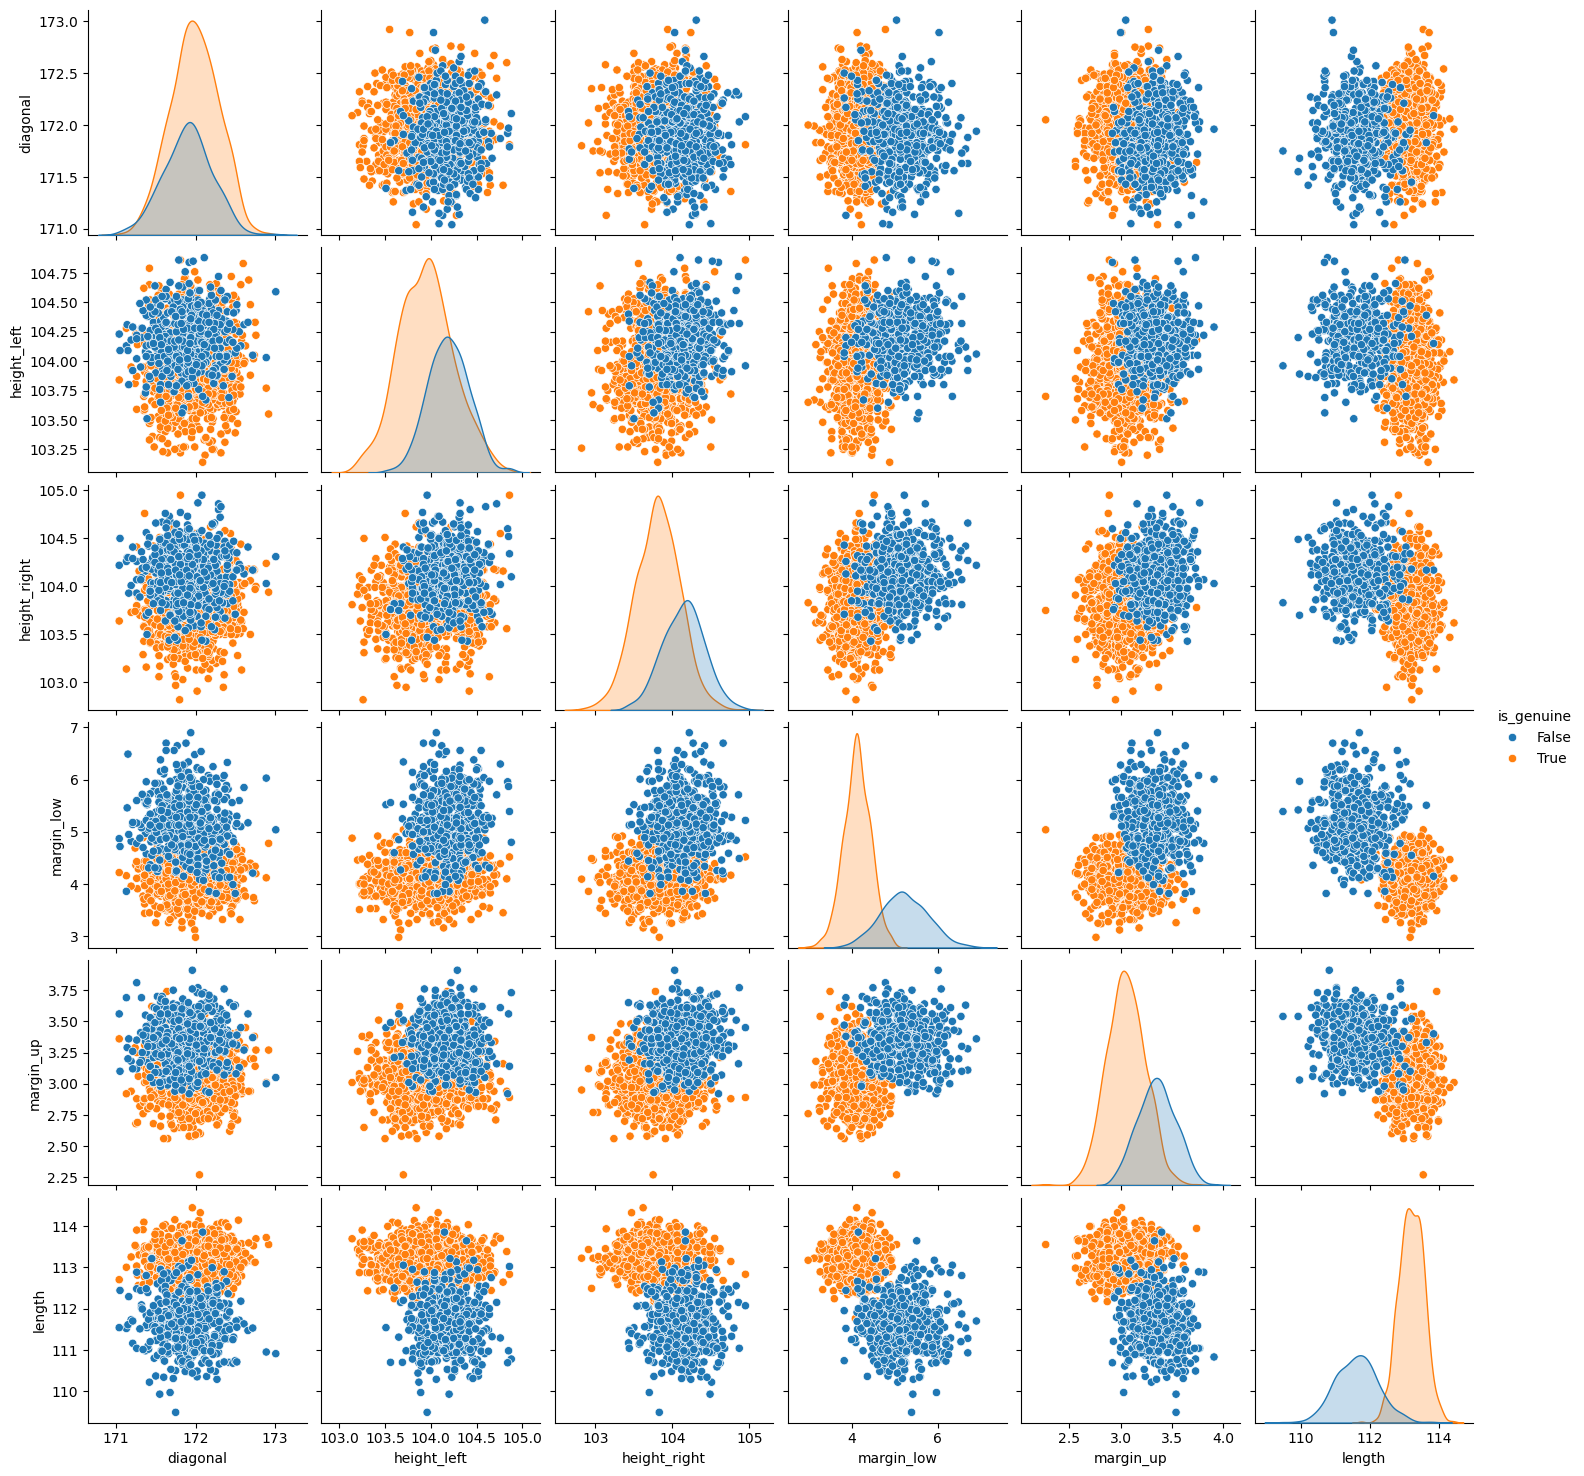

In [19]:
sns.pairplot(billets, hue = 'is_genuine')

In [20]:
#Régression logistique

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X = billets[['height_left', 'height_right', 'margin_low', 'margin_up', 'length']]
y = billets.is_genuine

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)
clf = LogisticRegression(random_state=808).fit(X_train, y_train)

print(f"Score de la classification R^2: ", clf.score(X_test, y_test))

Score de la classification R^2:  0.9966666666666667


In [22]:
y_pred = clf.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9966666666666667

In [24]:
from sklearn.metrics import confusion_matrix

In [25]:
confusion_matrix(y_test, y_pred)

array([[ 96,   1],
       [  0, 203]])

In [26]:
y_hat_proba = clf.predict_proba(X_test)[:,1]

In [27]:
for i in range(1, 10):
    y_pred_0x = [ 0 if value < i/10 else 1 for value in y_hat_proba ]
    threshold_name = f"y_pred_0{i}"
    print("Seuil de ", i/10)
    print("Matrice de confusion")
    print(confusion_matrix(y_test, y_pred_0x))
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_0x).ravel()
    print("Score de rappel : ", tp/(tp + fn))
    print("Score de précision : ", tp/(tp + fp), end = "\n\n")


Seuil de  0.1
Matrice de confusion
[[ 89   8]
 [  0 203]]
Score de rappel :  1.0
Score de précision :  0.9620853080568721

Seuil de  0.2
Matrice de confusion
[[ 92   5]
 [  0 203]]
Score de rappel :  1.0
Score de précision :  0.9759615384615384

Seuil de  0.3
Matrice de confusion
[[ 95   2]
 [  0 203]]
Score de rappel :  1.0
Score de précision :  0.9902439024390244

Seuil de  0.4
Matrice de confusion
[[ 96   1]
 [  0 203]]
Score de rappel :  1.0
Score de précision :  0.9950980392156863

Seuil de  0.5
Matrice de confusion
[[ 96   1]
 [  0 203]]
Score de rappel :  1.0
Score de précision :  0.9950980392156863

Seuil de  0.6
Matrice de confusion
[[ 96   1]
 [  0 203]]
Score de rappel :  1.0
Score de précision :  0.9950980392156863

Seuil de  0.7
Matrice de confusion
[[ 96   1]
 [  1 202]]
Score de rappel :  0.9950738916256158
Score de précision :  0.9950738916256158

Seuil de  0.8
Matrice de confusion
[[ 97   0]
 [  2 201]]
Score de rappel :  0.9901477832512315
Score de précision :  1.0

S

In [28]:
print(f"MSE : (y, y_pred): {mean_squared_error(y_test, y_pred)}")
print(f"MAE : (y, y_pred): {mean_absolute_error(y_test, y_pred)}")
print(f"MAPE : (y, y_pred): {mean_absolute_percentage_error(y_test, y_pred)}")

MSE : (y, y_pred): 0.0033333333333333335
MAE : (y, y_pred): 0.0033333333333333335
MAPE : (y, y_pred): 15011998757901.654


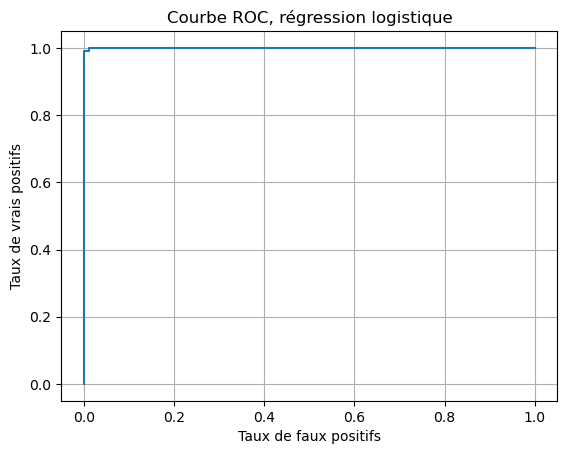

In [29]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_hat_proba)
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.grid()
plt.title("Courbe ROC, régression logistique")
plt.plot(fpr, tpr)


In [30]:
from sklearn.model_selection import cross_val_score

In [31]:
from sklearn.model_selection import cross_val_predict
from sklearn import metrics
predicted = cross_val_predict(clf, X, y, cv=5)
print (metrics.accuracy_score(y, predicted))

0.99


In [32]:
print (metrics.classification_report(y, predicted))

              precision    recall  f1-score   support

       False       0.99      0.98      0.98       500
        True       0.99      0.99      0.99      1000

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500



In [33]:
scores = cross_val_score(clf, X, y, cv=5)
print("Scores de validation croisée:", scores)
print("Moyenne des scores de précision:", scores.mean())

Scores de validation croisée: [0.98666667 0.98666667 0.99666667 0.98666667 0.99333333]
Moyenne des scores de précision: 0.99


In [34]:
from sklearn.model_selection import KFold
from sklearn.metrics import recall_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

confusion_matrices = []
recall_scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index] if hasattr(X, 'iloc') else X[train_index], \
                      X.iloc[test_index] if hasattr(X, 'iloc') else X[test_index]
    y_train, y_test = y.iloc[train_index] if hasattr(y, 'iloc') else y[train_index], \
                      y.iloc[test_index] if hasattr(y, 'iloc') else y[test_index]
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='macro')
    confusion_matrices.append(cm)
    recall_scores.append(recall)

for i, (cm, recall) in enumerate(zip(confusion_matrices, recall_scores)):
    print(f"Fold {i+1}:")
    print("Confusion Matrix:")
    print(cm)
    print(f"Recall Score: {recall:.4f}")
    print("-" * 40)

print(f"Mean Recall Score: {np.mean(recall_scores):.4f}")




Fold 1:
Confusion Matrix:
[[107   3]
 [  0 190]]
Recall Score: 0.9864
----------------------------------------
Fold 2:
Confusion Matrix:
[[ 96   2]
 [  2 200]]
Recall Score: 0.9848
----------------------------------------
Fold 3:
Confusion Matrix:
[[ 87   2]
 [  0 211]]
Recall Score: 0.9888
----------------------------------------
Fold 4:
Confusion Matrix:
[[ 87   1]
 [  2 210]]
Recall Score: 0.9896
----------------------------------------
Fold 5:
Confusion Matrix:
[[113   2]
 [  0 185]]
Recall Score: 0.9913
----------------------------------------
Mean Recall Score: 0.9882


<Axes: ylabel='Count'>

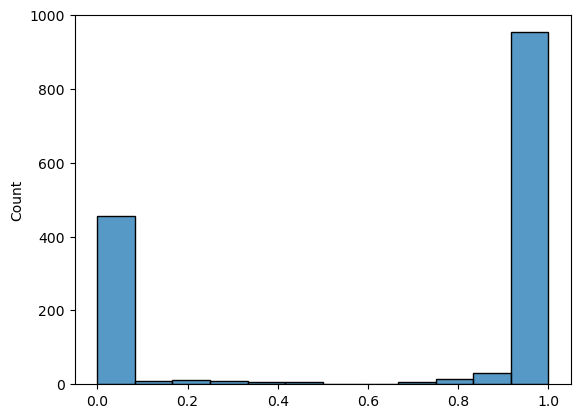

In [35]:
y_hat_proba = clf.predict_proba(X)[:,1]
sns.histplot(y_hat_proba)

In [36]:
#K-means

In [37]:
from sklearn.cluster import KMeans

In [38]:
billets_k = billets.copy()
X = billets_k[['height_left', 'height_right', 'margin_low', 'margin_up', 'length']]
y = billets_k.is_genuine

C:\Users\agall\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\agall\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\agall\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\agall\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

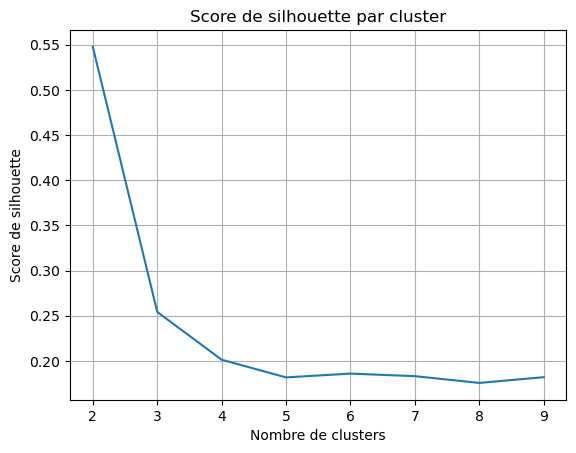

In [39]:
from sklearn.metrics import silhouette_score
score_silhouette = []
index = []
k_list =range(2, 10)
for k in k_list : 
    k_means = KMeans(n_clusters=k)
    k_means.fit(X)
    k_means_labels = k_means.predict(X)
    score_silhouette.append(silhouette_score(X,k_means_labels ))
    index.append(k)
plt.plot(index, score_silhouette)
plt.xlabel("Nombre de clusters")
plt.ylabel("Score de silhouette")
plt.title("Score de silhouette par cluster")
plt.grid()
plt.show()


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

In [41]:
k_means = KMeans( n_clusters=2, random_state = 808)
k_means.fit(X)
print(k_means.cluster_centers_)


[[104.19222917 104.146375     5.24176066   3.34845833 111.58283333]
 [103.95297059 103.81392157   4.12570736   3.05877451 113.19410784]]


C:\Users\agall\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


In [42]:
print("score", k_means.score(X))
print("Score de silhouette ", silhouette_score(X,k_means.labels_ ))

score -832.3039069189496
Score de silhouette  0.5475202062316757


In [43]:
from sklearn.metrics import accuracy_score, recall_score

labels = k_means.labels_.copy()
print("confusion_matrix\n",confusion_matrix(y,labels ))
print("accuracy_score",accuracy_score(y,labels ))
print("accuracy_score",accuracy_score(y,labels ))
print(set(labels))

confusion_matrix
 [[478  22]
 [  2 998]]
accuracy_score 0.984
accuracy_score 0.984
{np.int32(0), np.int32(1)}


In [44]:
print(f"MSE : (y, y_pred): {mean_squared_error(y,labels )}")
print(f"MAE : (y, y_pred): {mean_absolute_error(y,labels )}")
print(f"MAPE : (y, y_pred): {mean_absolute_percentage_error(y,labels )}")

MSE : (y, y_pred): 0.016
MAE : (y, y_pred): 0.016
MAPE : (y, y_pred): 66052794534767.27


In [45]:
predicted = cross_val_predict(k_means, X, y, cv=5)
print (metrics.accuracy_score(y, predicted))
print (metrics.classification_report(y, predicted))

C:\Users\agall\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\agall\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\agall\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\agall\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

0.984
              precision    recall  f1-score   support

       False       1.00      0.96      0.98       500
        True       0.98      1.00      0.99      1000

    accuracy                           0.98      1500
   macro avg       0.99      0.98      0.98      1500
weighted avg       0.98      0.98      0.98      1500



In [46]:
from sklearn.metrics import adjusted_rand_score
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
ari_scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    k_means.fit(X_train)
    y_pred = k_means.predict(X_test)
    ari = adjusted_rand_score(y.iloc[test_index] if hasattr(y, 'iloc') else y[test_index], y_pred)
    ari_scores.append(ari)



print("Adjusted Rand Index scores:", ari_scores)
print("Mean Adjusted Rand Index:", sum(ari_scores) / len(ari_scores))



Adjusted Rand Index scores: [0.9208478892510347, 0.9464057804245841, 0.9187371780852216, 0.9455611787644245, 0.9470266140328537]
Mean Adjusted Rand Index: 0.9357157281116237


C:\Users\agall\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\agall\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\agall\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\agall\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: ylabel='Count'>

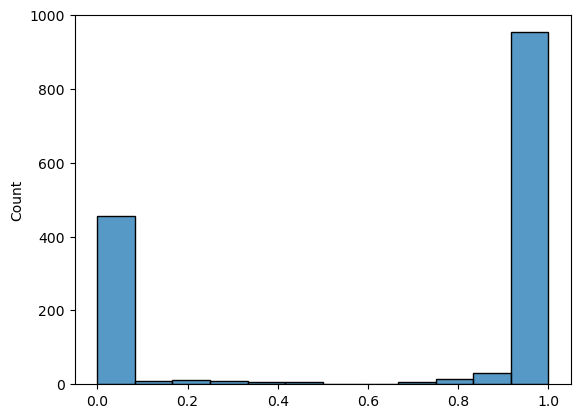

In [47]:
y_hat_proba = clf.predict_proba(X)[:,1]
sns.histplot(y_hat_proba)

In [48]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

confusion_matrices = []
recall_scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index] if hasattr(X, 'iloc') else X[train_index], \
                      X.iloc[test_index] if hasattr(X, 'iloc') else X[test_index]
    y_train, y_test = y.iloc[train_index] if hasattr(y, 'iloc') else y[train_index], \
                      y.iloc[test_index] if hasattr(y, 'iloc') else y[test_index]
    k_means.fit(X_train, y_train)
    y_pred = k_means.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='macro')
    confusion_matrices.append(cm)
    recall_scores.append(recall)

for i, (cm, recall) in enumerate(zip(confusion_matrices, recall_scores)):
    print(f"Fold {i+1}:")
    print("Confusion Matrix:")
    print(cm)
    print(f"Recall Score: {recall:.4f}")
    print("-" * 40)

print(f"Mean Recall Score: {np.mean(recall_scores):.4f}")

Fold 1:
Confusion Matrix:
[[104   6]
 [  0 190]]
Recall Score: 0.9727
----------------------------------------
Fold 2:
Confusion Matrix:
[[ 95   3]
 [  1 201]]
Recall Score: 0.9822
----------------------------------------
Fold 3:
Confusion Matrix:
[[ 83   6]
 [  0 211]]
Recall Score: 0.9663
----------------------------------------
Fold 4:
Confusion Matrix:
[[ 85   3]
 [  1 211]]
Recall Score: 0.9806
----------------------------------------
Fold 5:
Confusion Matrix:
[[111   4]
 [  0 185]]
Recall Score: 0.9826
----------------------------------------
Mean Recall Score: 0.9769


C:\Users\agall\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\agall\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\agall\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\agall\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [49]:
#KNN

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [51]:
billets_knn = billets.copy()
X = billets_knn[['height_left', 'height_right', 'margin_low', 'margin_up', 'length']]
y = billets_knn.is_genuine

In [52]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [53]:
for i in range(1, 10, 2) : 
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    print(f"Score de précision (k={i}): {accuracy_score(y_test, y_pred):.3f}")
    print(f"Score de rappel (k={i}): {recall_score(y_test, y_pred):.3f}", end = "\n\n")

Score de précision (k=1): 0.990
Score de rappel (k=1): 0.989

Score de précision (k=3): 0.987
Score de rappel (k=3): 1.000

Score de précision (k=5): 0.987
Score de rappel (k=5): 1.000

Score de précision (k=7): 0.987
Score de rappel (k=7): 1.000

Score de précision (k=9): 0.987
Score de rappel (k=9): 1.000



In [54]:
best_knn = KNeighborsClassifier(n_neighbors=3)
best_knn.fit(X_train, y_train)

y_pred = best_knn.predict(X_test)

In [55]:
confusion_matrix(y_test, y_pred)

array([[106,   4],
       [  0, 190]])

In [56]:
print(f"MSE : (y, y_pred): {mean_squared_error(y_test, y_pred)}")
print(f"MAE : (y, y_pred): {mean_absolute_error(y_test, y_pred)}")
print(f"MAPE : (y, y_pred): {mean_absolute_percentage_error(y_test, y_pred)}")

MSE : (y, y_pred): 0.013333333333333334
MAE : (y, y_pred): 0.013333333333333334
MAPE : (y, y_pred): 60047995031606.62


In [57]:
predicted = cross_val_predict(best_knn, X, y, cv=5)
print (metrics.accuracy_score(y, predicted))
print (metrics.classification_report(y, predicted))

0.9906666666666667
              precision    recall  f1-score   support

       False       0.99      0.98      0.99       500
        True       0.99      1.00      0.99      1000

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500



In [58]:
scores = cross_val_score(best_knn, X, y, cv=5)
print("Scores de validation croisée:", scores)
print("Moyenne des scores de précision:", scores.mean())

Scores de validation croisée: [0.98666667 0.98666667 0.99666667 0.99333333 0.99      ]
Moyenne des scores de précision: 0.9906666666666666


In [59]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

confusion_matrices = []
recall_scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index] if hasattr(X, 'iloc') else X[train_index], \
                      X.iloc[test_index] if hasattr(X, 'iloc') else X[test_index]
    y_train, y_test = y.iloc[train_index] if hasattr(y, 'iloc') else y[train_index], \
                      y.iloc[test_index] if hasattr(y, 'iloc') else y[test_index]
    best_knn.fit(X_train, y_train)
    y_pred = best_knn.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='macro')
    confusion_matrices.append(cm)
    recall_scores.append(recall)

for i, (cm, recall) in enumerate(zip(confusion_matrices, recall_scores)):
    print(f"Fold {i+1}:")
    print("Confusion Matrix:")
    print(cm)
    print(f"Recall Score: {recall:.4f}")
    print("-" * 40)

print(f"Mean Recall Score: {np.mean(recall_scores):.4f}")

Fold 1:
Confusion Matrix:
[[106   4]
 [  0 190]]
Recall Score: 0.9818
----------------------------------------
Fold 2:
Confusion Matrix:
[[ 96   2]
 [  1 201]]
Recall Score: 0.9873
----------------------------------------
Fold 3:
Confusion Matrix:
[[ 87   2]
 [  0 211]]
Recall Score: 0.9888
----------------------------------------
Fold 4:
Confusion Matrix:
[[ 87   1]
 [  2 210]]
Recall Score: 0.9896
----------------------------------------
Fold 5:
Confusion Matrix:
[[113   2]
 [  0 185]]
Recall Score: 0.9913
----------------------------------------
Mean Recall Score: 0.9878


In [60]:
#Forêt aléatoire

In [61]:
billets_rf = billets.copy()
X = billets_rf[['height_left', 'height_right', 'margin_low', 'margin_up', 'length']]
y = billets_rf.is_genuine

In [62]:
from sklearn.ensemble import RandomForestClassifier

In [63]:
accuracy = []
tree_counts = [1,2,3,4,5,10,15,20,25,30,40,50, 60, 70, 80, 90, 100, 110, 120]
X_train, X_test, y_train, y_test = train_test_split( X, y, train_size=0.8, random_state=8)

accuracy  = []
for n_estimator in tree_counts:
    clf = RandomForestClassifier(
        n_estimators = n_estimator,
        max_depth = 2,
        random_state = 8
        )

    clf.fit(X_train, y_train)
    accuracy.append(clf.score(X_test, y_test))


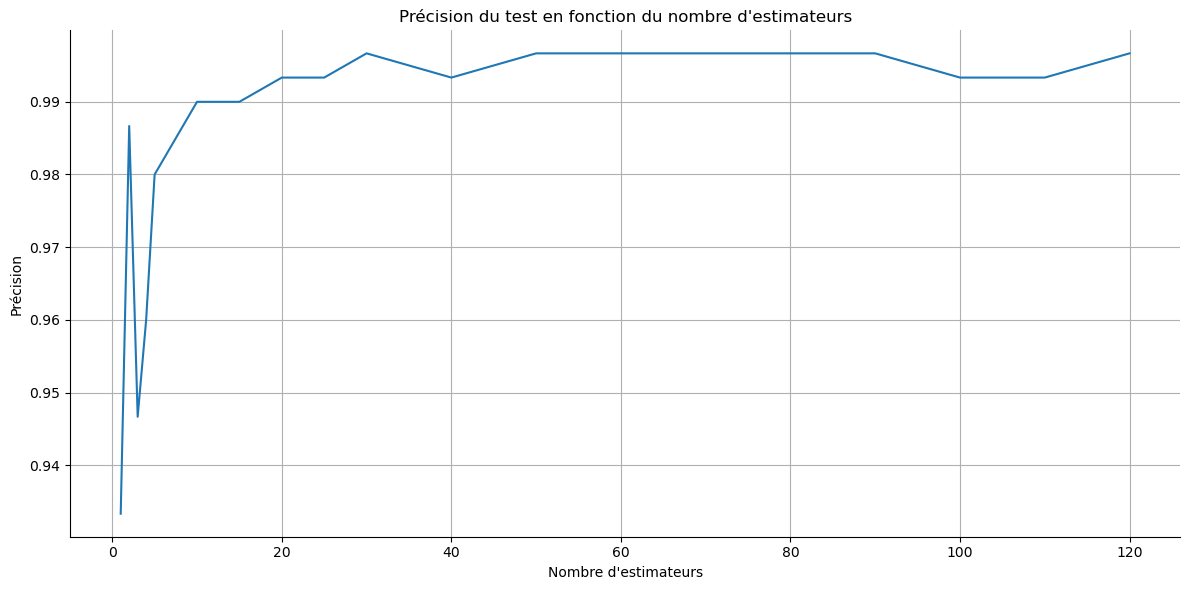

In [64]:
fig = plt.figure(figsize = (12, 6))
ax = fig.add_subplot(1, 1, 1)

plt.plot(tree_counts, accuracy)
ax.set_title("Précision du test en fonction du nombre d'estimateurs")
ax.set_xlabel("Nombre d'estimateurs")
ax.set_ylabel("Précision")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid()
plt.tight_layout()

In [65]:
clf = RandomForestClassifier(
            n_estimators = n_estimator,
            max_depth = None,
            max_features = None,
            random_state = 8
            )

In [66]:
tree_counts = [1,2,3,4,5,10,15,20,25,30,40,50, 60, 70, 80, 90, 100, 110, 120, 150]
accuracy  = []

for n_estimators in tree_counts : 
     clf = RandomForestClassifier(
        n_estimators = n_estimators,
        max_depth = None,
        max_features = None,
        random_state = 8
        )
     clf.fit(X_train, y_train)
     accuracy.append({
        "n" : n_estimators,
        "test" : clf.score(X_test, y_test),
        "train" : clf.score(X_train, y_train),
     })

        

In [67]:
accuracy = pd.DataFrame(accuracy)
accuracy['delta'] = np.abs(accuracy.train - accuracy.test)

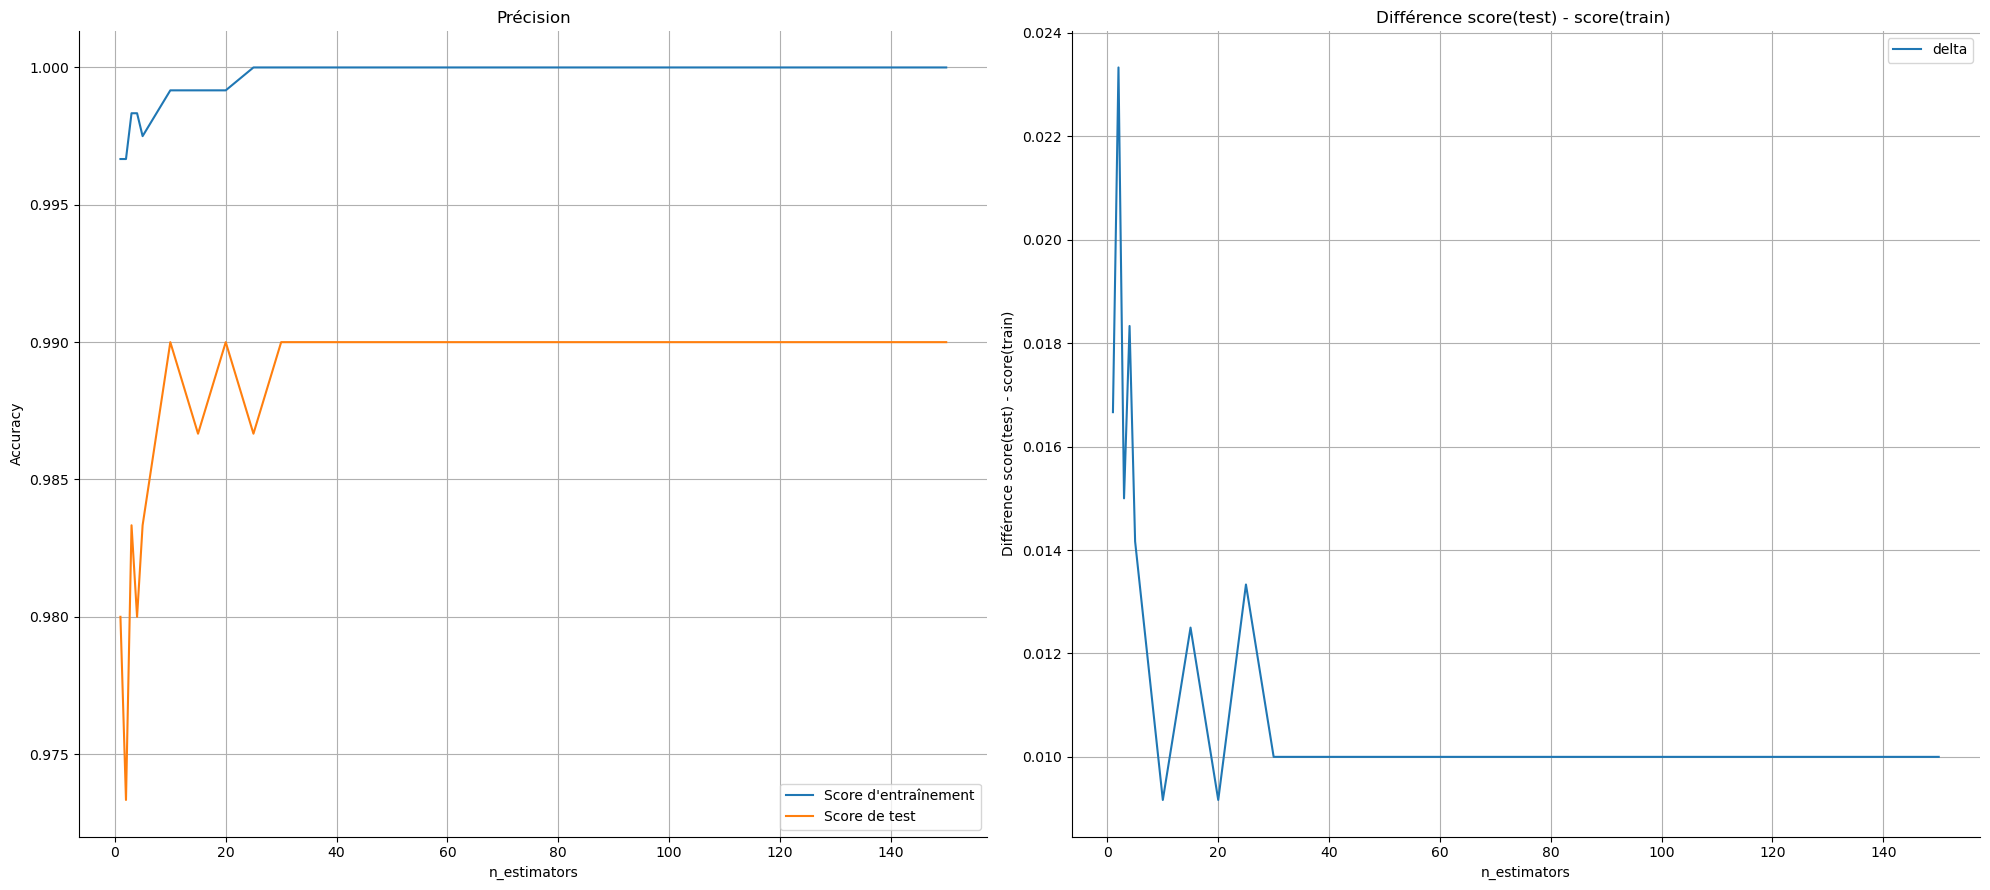

In [68]:
fig = plt.figure(figsize = (20, 9))
ax = fig.add_subplot(1, 2, 1)

plt.plot(accuracy.n, accuracy.train, label = "Score d'entraînement")
plt.plot(accuracy.n, accuracy.test, label = "Score de test")

ax.grid(True, which = 'both')
ax.set_title("Précision")
ax.set_xlabel('n_estimators')
ax.set_ylabel('Accuracy')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

ax = fig.add_subplot(1, 2, 2)
plt.plot(accuracy.n, accuracy.delta, label = 'delta')

ax.grid(True, which = 'both')
ax.set_title('Différence score(test) - score(train) ')
ax.set_xlabel('n_estimators')
ax.set_ylabel('Différence score(test) - score(train)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()
plt.tight_layout()

In [69]:
billets_rf = billets.copy()
X = billets_rf[['height_left', 'height_right', 'margin_low', 'margin_up', 'length']]
y = billets_rf.is_genuine

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [70]:
clf = RandomForestClassifier(
    n_estimators = 100,
    random_state = 8
    )

clf.fit(X_train, y_train)
print("test :",np.round(clf.score(X_test, y_test), 3))
print('train:', np.round(clf.score(X_train, y_train), 3))
print(clf.feature_importances_)

test : 0.993
train: 1.0
[0.02101427 0.0356485  0.32891287 0.10540374 0.50902061]


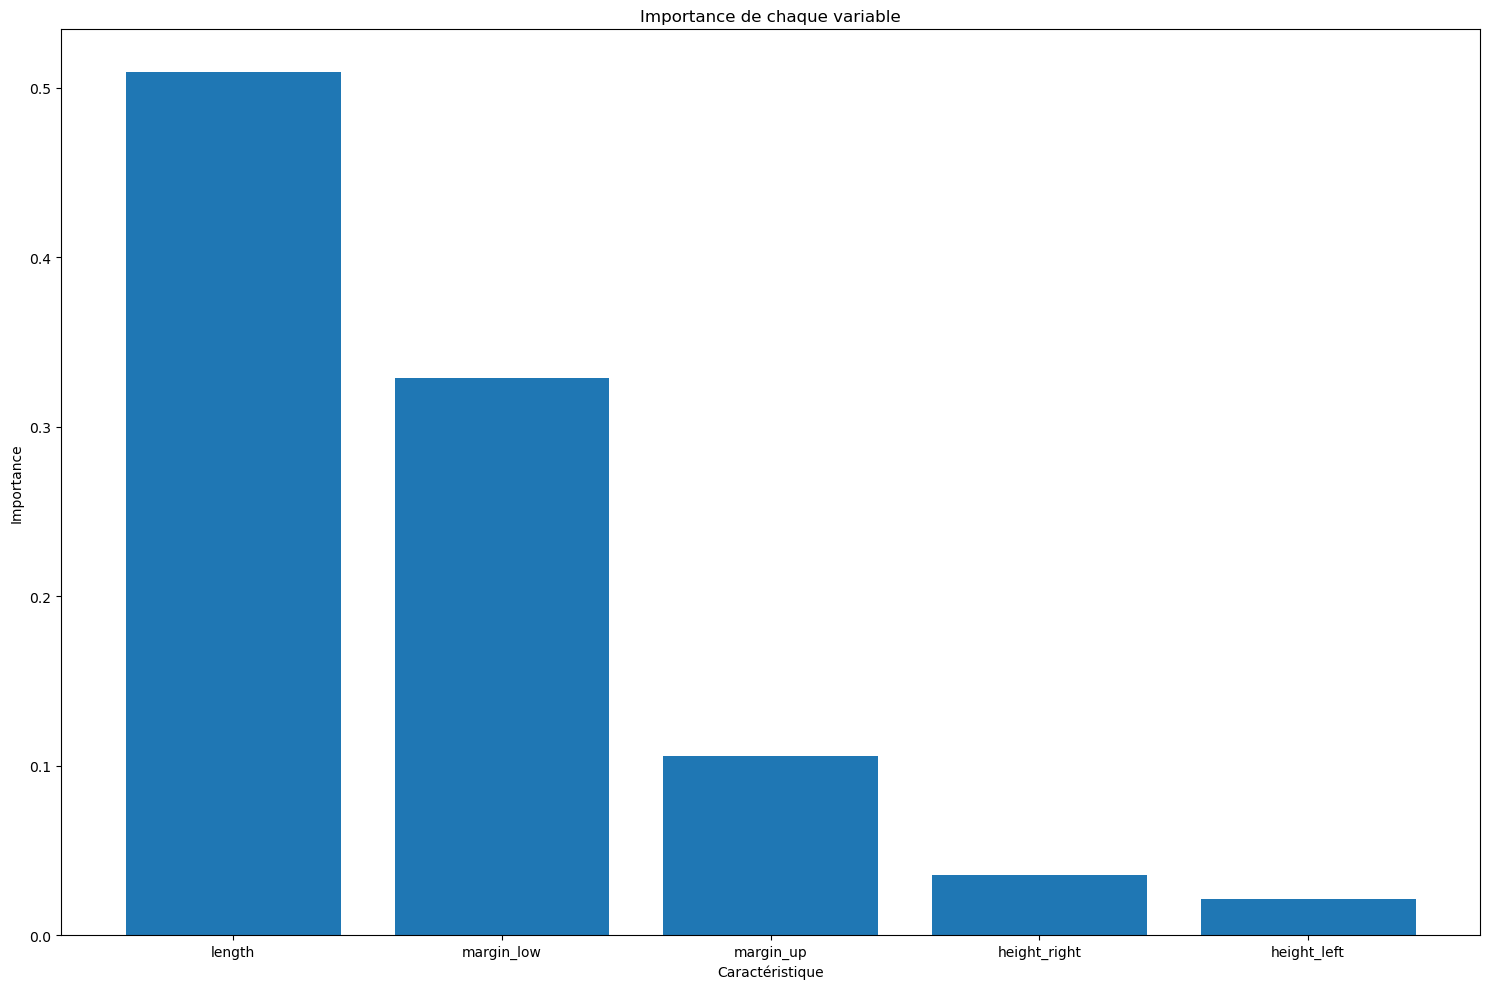

In [71]:
df_feature = pd.DataFrame()
df_feature['Caractéristique'] = X.columns
df_feature['Importance'] = clf.feature_importances_
df_feature = df_feature.sort_values(by = 'Importance', ascending = False)

fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)

ax.bar(df_feature['Caractéristique'], df_feature['Importance'])
ax.set_xlabel('Caractéristique')
ax.set_ylabel('Importance')
ax.set_title('Importance de chaque variable')
plt.tight_layout()

In [72]:
from sklearn.ensemble import RandomForestRegressor

In [73]:
regressor = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    oob_score=True
)

regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, oob_score=True, random_state=42)

In [74]:
from sklearn.metrics import mean_squared_error, r2_score
print("Out-of-Bag Score:", regressor.oob_score_)

y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

r2 = r2_score(y_test, y_pred)
print("R²:", r2)

Out-of-Bag Score: 0.9452154586393611
MSE: 0.007949333333333333
R²: 0.9657684210526316


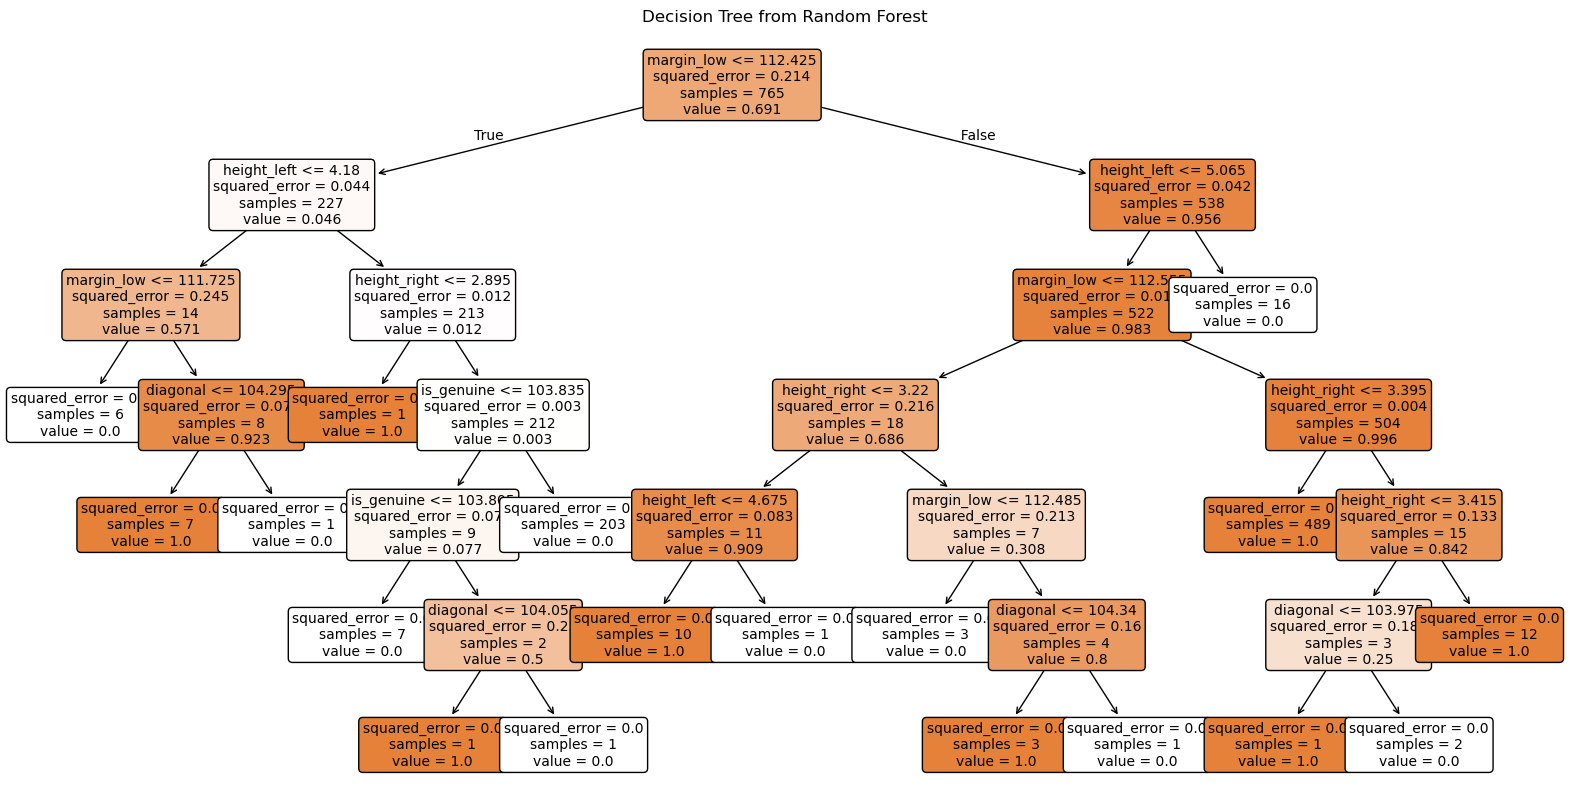

In [75]:
from sklearn.tree import plot_tree

tree_to_plot = regressor.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(tree_to_plot, feature_names=billets_rf.columns.tolist(), filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree from Random Forest")
plt.show()

In [76]:
y_train_hat = regressor.predict(X_train)
y_test_hat = regressor.predict(X_test)
y_test_hat_binary = (y_test_hat > 0.5).astype(int)
print(confusion_matrix(y_test, y_test_hat_binary))
tn, fp, fn, tp = confusion_matrix(y_test, y_test_hat_binary).ravel()
print("Score de rappel : ", tp/(tp + fn))
print("Score de précision : ", tp/(tp + fp))

[[107   3]
 [  0 190]]
Score de rappel :  1.0
Score de précision :  0.9844559585492227


In [77]:
predicted = cross_val_predict(regressor, X, y, cv=5)
classifier = RandomForestClassifier(n_estimators=50, random_state=42)
    
scores = cross_val_score(classifier, X, y, cv=5)
print("Cross-validation accuracy scores:", scores)
print("Mean accuracy score:", scores.mean())


Cross-validation accuracy scores: [0.99333333 0.98666667 0.99666667 0.99333333 0.98666667]
Mean accuracy score: 0.9913333333333332


In [78]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

confusion_matrices = []
recall_scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index] if hasattr(X, 'iloc') else X[train_index], \
                      X.iloc[test_index] if hasattr(X, 'iloc') else X[test_index]
    y_train, y_test = y.iloc[train_index] if hasattr(y, 'iloc') else y[train_index], \
                      y.iloc[test_index] if hasattr(y, 'iloc') else y[test_index]
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='macro')
    confusion_matrices.append(cm)
    recall_scores.append(recall)

for i, (cm, recall) in enumerate(zip(confusion_matrices, recall_scores)):
    print(f"Fold {i+1}:")
    print("Confusion Matrix:")
    print(cm)
    print(f"Recall Score: {recall:.4f}")
    print("-" * 40)

print(f"Mean Recall Score: {np.mean(recall_scores):.4f}")

Fold 1:
Confusion Matrix:
[[107   3]
 [  1 189]]
Recall Score: 0.9837
----------------------------------------
Fold 2:
Confusion Matrix:
[[ 96   2]
 [  2 200]]
Recall Score: 0.9848
----------------------------------------
Fold 3:
Confusion Matrix:
[[ 86   3]
 [  0 211]]
Recall Score: 0.9831
----------------------------------------
Fold 4:
Confusion Matrix:
[[ 87   1]
 [  2 210]]
Recall Score: 0.9896
----------------------------------------
Fold 5:
Confusion Matrix:
[[113   2]
 [  2 183]]
Recall Score: 0.9859
----------------------------------------
Mean Recall Score: 0.9854


In [75]:
from sklearn.tree import DecisionTreeClassifier

In [76]:
billets_rf = billets.copy()
X = billets_rf[['height_left', 'height_right', 'margin_low', 'margin_up', 'length']]
y = billets_rf.is_genuine

X_train, X_test, y_train, y_test = train_test_split( X, y, train_size=0.8, random_state=8)

In [77]:
clf = DecisionTreeClassifier(
        max_depth = 3,
    random_state = 808
)
clf.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=808)

In [78]:
from sklearn.metrics import roc_auc_score
train_auc = roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])

print("train",train_auc)
print("test", test_auc)


train 0.9950451377199218
test 0.9889876742776318


In [79]:
y_train_hat = clf.predict(X_train)
y_test_hat = clf.predict(X_test)
print(confusion_matrix(y_test, y_test_hat))


[[ 95   3]
 [  0 202]]


In [80]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_hat))

              precision    recall  f1-score   support

       False       1.00      0.97      0.98        98
        True       0.99      1.00      0.99       202

    accuracy                           0.99       300
   macro avg       0.99      0.98      0.99       300
weighted avg       0.99      0.99      0.99       300



In [81]:
clf.score(X_train, y_train)


0.985

In [82]:
clf.score(X_test, y_test)


0.99

In [83]:
scores = []
for depth in np.arange(2, 30, 2):
    clf = DecisionTreeClassifier(
        max_depth = depth,
        random_state = 808
    )

    clf.fit(X_train, y_train)

    train_auc = roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1], multi_class='ovr')
    test_auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1], multi_class='ovr')
    scores.append({
        'max_depth': depth,
        'train': train_auc,
        'test': test_auc,
    })

scores = pd.DataFrame(scores)


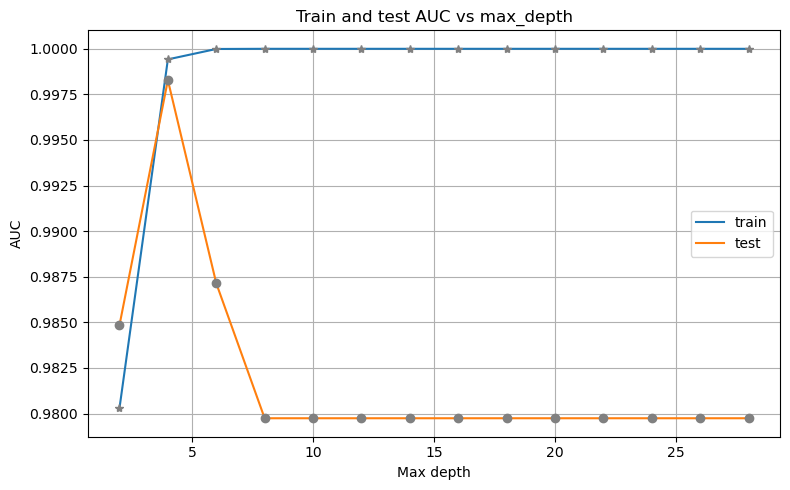

In [84]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1, 1, 1)
plt.plot(scores.max_depth, scores.train, label = 'train')
plt.plot(scores.max_depth, scores.test, label = 'test')
plt.plot(scores.max_depth, scores.train, '*', color = 'gray')
plt.plot(scores.max_depth, scores.test, 'o', color = 'gray')
ax.grid(True, which = 'both')
ax.set_title('Train and test AUC vs max_depth')
ax.set_xlabel('Max depth')
ax.set_ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()



In [85]:
clf = DecisionTreeClassifier(
        max_depth = 6,
    random_state = 808
)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=808)

In [86]:
y_train_hat = clf.predict(X_train)
y_test_hat = clf.predict(X_test)
print(confusion_matrix(y_test, y_test_hat))
tn, fp, fn, tp = confusion_matrix(y_test, y_test_hat).ravel()
print("Score de rappel : ", tp/(tp + fn))
print("Score de précision : ", tp/(tp + fp), end = "\n\n")

[[ 95   3]
 [  1 201]]
Score de rappel :  0.995049504950495
Score de précision :  0.9852941176470589



In [87]:
billets_a_verifier = billets.copy()
billets_a_verifier = billets_a_verifier.sample(n=10, random_state = 42)
display(billets_a_verifier)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
1116,False,172.26,103.90,104.12,4.990000,3.42,111.27
1368,False,171.65,104.32,104.38,5.650000,3.24,112.30
422,True,171.53,103.53,103.63,4.040000,2.96,112.76
413,True,172.30,103.66,103.50,4.073633,3.16,112.95
451,True,172.17,103.79,103.54,4.070000,2.78,113.03
861,True,171.86,104.21,103.74,4.430000,2.90,113.65
1063,False,171.44,103.99,104.04,4.810000,3.49,111.74
741,True,172.17,103.75,103.29,4.430000,2.88,113.38
1272,False,171.73,103.74,104.38,5.140000,3.16,111.73
259,True,172.35,103.62,103.78,4.380000,2.86,113.28


In [88]:
billets_a_verifier['is_genuine'] = np.nan
display(billets_a_verifier)

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
1116,NaN,172.26,103.90,104.12,4.990000,3.42,111.27
1368,NaN,171.65,104.32,104.38,5.650000,3.24,112.30
422,NaN,171.53,103.53,103.63,4.040000,2.96,112.76
413,NaN,172.30,103.66,103.50,4.073633,3.16,112.95
451,NaN,172.17,103.79,103.54,4.070000,2.78,113.03
861,NaN,171.86,104.21,103.74,4.430000,2.90,113.65
1063,NaN,171.44,103.99,104.04,4.810000,3.49,111.74
741,NaN,172.17,103.75,103.29,4.430000,2.88,113.38
1272,NaN,171.73,103.74,104.38,5.140000,3.16,111.73
259,NaN,172.35,103.62,103.78,4.380000,2.86,113.28


In [90]:
billets_a_verifier.to_csv('billets_a_verifier.csv', sep = ";")

In [91]:
billets_a_verifier = pd.read_csv("billets_a_verifier.csv", delimiter = ";")
display(billets_a_verifier)

,Unnamed: 0,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,1116,NaN,172.26,103.90,104.12,4.990000,3.42,111.27
1,1368,NaN,171.65,104.32,104.38,5.650000,3.24,112.30
2,422,NaN,171.53,103.53,103.63,4.040000,2.96,112.76
3,413,NaN,172.30,103.66,103.50,4.073633,3.16,112.95
4,451,NaN,172.17,103.79,103.54,4.070000,2.78,113.03
5,861,NaN,171.86,104.21,103.74,4.430000,2.90,113.65
6,1063,NaN,171.44,103.99,104.04,4.810000,3.49,111.74
7,741,NaN,172.17,103.75,103.29,4.430000,2.88,113.38
8,1272,NaN,171.73,103.74,104.38,5.140000,3.16,111.73
9,259,NaN,172.35,103.62,103.78,4.380000,2.86,113.28


In [94]:
billets_rl = billets.copy()
X = billets_rl[['height_left', 'height_right', 'margin_low', 'margin_up', 'length', 'diagonal']]
y = billets_rl.is_genuine

clf = LogisticRegression(random_state=808).fit(X, y)


nan_mask = billets_a_verifier.is_genuine.isna()
X_predict = billets_a_verifier.loc[nan_mask, ['height_left', 'height_right', 'margin_low', 'margin_up', 'length', 'diagonal']]
y_pred = clf.predict(X_predict)

billets_a_verifier.loc[nan_mask, 'is_genuine'] = y_pred

display(billets_a_verifier)

C:\Users\agall\AppData\Local\Temp\ipykernel_38008\2164659380.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False  True  True  True  True False  True False  True]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  billets_a_verifier.loc[nan_mask, 'is_genuine'] = y_pred


,Unnamed: 0,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,1116,False,172.26,103.90,104.12,4.990000,3.42,111.27
1,1368,False,171.65,104.32,104.38,5.650000,3.24,112.30
2,422,True,171.53,103.53,103.63,4.040000,2.96,112.76
3,413,True,172.30,103.66,103.50,4.073633,3.16,112.95
4,451,True,172.17,103.79,103.54,4.070000,2.78,113.03
5,861,True,171.86,104.21,103.74,4.430000,2.90,113.65
6,1063,False,171.44,103.99,104.04,4.810000,3.49,111.74
7,741,True,172.17,103.75,103.29,4.430000,2.88,113.38
8,1272,False,171.73,103.74,104.38,5.140000,3.16,111.73
9,259,True,172.35,103.62,103.78,4.380000,2.86,113.28
